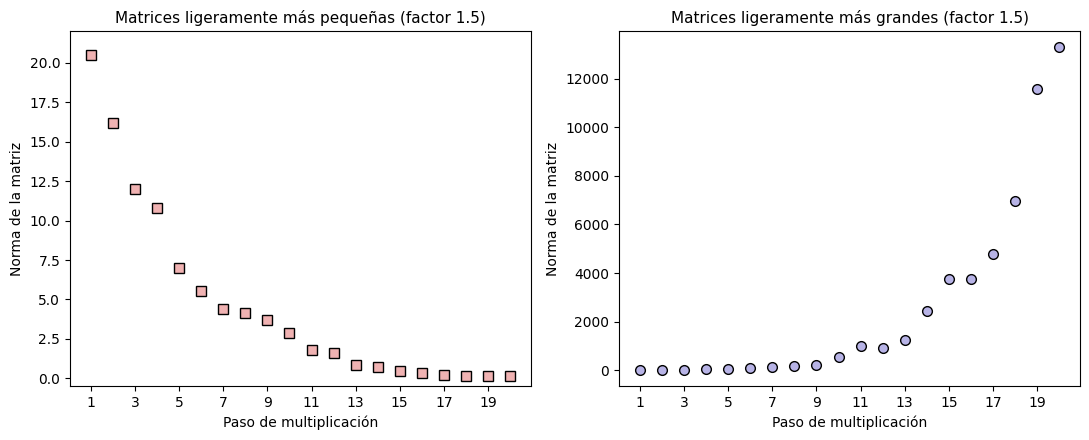

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Fijar semilla para reproducibilidad
np.random.seed(42)

steps = 20
dim = 8  # Dimensión de las matrices (8x8)

# --- 1. Simulación: Matrices ligeramente más pequeñas (Factor / 1.5) ---
norms_smaller = []
A = np.random.randn(dim, dim)
A = A * (20.5 / np.linalg.norm(A))  # Ajustar norma inicial cerca de 20

for step in range(steps):
  norms_smaller.append(np.linalg.norm(A))
  # Matriz ortogonal/aleatoria escalada hacia abajo
  W = np.random.randn(dim, dim) / np.sqrt(dim)
  A = A @ (W / 1.28)

# --- 2. Simulación: Matrices ligeramente más grandes (Factor * 1.5) ---
norms_larger = []
B = np.random.randn(dim, dim)
B = B * (15.0 / np.linalg.norm(B))

for step in range(steps):
  norms_larger.append(np.linalg.norm(B))
  # Matriz ortogonal/aleatoria escalada hacia arriba
  W = np.random.randn(dim, dim) / np.sqrt(dim)
  B = B @ (W * 1.38)

# --- 3. Renderizado de la figura con Matplotlib ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
x_axis = np.arange(1, steps + 1)

# Panel Izquierdo: Colapso hacia cero
ax1.plot(
    x_axis,
    norms_smaller,
    "s",
    color="#f0b2b2",
    markeredgecolor="black",
    markersize=7,
)
ax1.set_title("Matrices ligeramente más pequeñas (factor 1.5)", fontsize=11)
ax1.set_xlabel("Paso de multiplicación", fontsize=10)
ax1.set_ylabel("Norma de la matriz", fontsize=10)
ax1.set_xticks(np.arange(1, 21, 2))
ax1.set_ylim(-0.5, 22)

# Panel Derecho: Explosión hacia el infinito
ax2.plot(
    x_axis,
    norms_larger,
    "o",
    color="#b7b3e6",
    markeredgecolor="black",
    markersize=7,
)
ax2.set_title("Matrices ligeramente más grandes (factor 1.5)", fontsize=11)
ax2.set_xlabel("Paso de multiplicación", fontsize=10)
ax2.set_ylabel("Norma de la matriz", fontsize=10)
ax2.set_xticks(np.arange(1, 21, 2))

plt.tight_layout()
plt.show()

La técnica de **Layer Normalization (LayerNorm)** es uno de los pilares fundamentales del *Deep Learning* moderno (esencial en arquitecturas como los Transformers). Es conceptualmente muy fácil de entender en términos matemáticos y sumamente sencilla de aplicar en la práctica.

---

### ¿Por qué necesitamos una técnica como LayerNorm?

Para comprender su necesidad, observemos el experimento ilustrado en los gráficos: se toma una matriz de números aleatorios y se multiplica sucesivamente por otras 20 matrices aleatorias del mismo tamaño.

Lo que mide el eje vertical en ambos gráficos es la **norma de la matriz** (un valor escalar que cuantifica la escala o magnitud global de los elementos dentro de la matriz):

* **Gráfico Izquierdo (Colapso hacia cero):** Al aplicar un factor de reducción leve (dividiendo por $1.5$ en cada paso), la norma de la matriz cae en picada y colapsa rápidamente a cero.
* **Gráfico Derecho (Explosión hacia el infinito):** Al aplicar un factor de escala ligeramente mayor (multiplicando por $1.5$), la norma crece de forma exponencial hasta explotar hacia el infinito.

---

### El impacto en los modelos de Deep Learning

Cuando multiplicamos matrices consecutivamente a través de decenas de capas en una red neuronal profunda, los valores numéricos tienden de forma natural a irse a cualquiera de estos dos extremos.

Si los valores numéricos se vuelven extremos, la estabilidad de la red colapsa:

1. **Gradientes desvanecidos (*Vanishing Gradients*):** Si los números caen a cero, la red pierde la capacidad de propagar información y deja de aprender.
2. **Gradientes explosivos (*Exploding Gradients*):** Si los números explotan, surgen errores de desbordamiento de punto flotante (`NaN` o `Inf`), imposibilitando cualquier cálculo.

La **estabilidad numérica** es uno de los mayores desafíos en el aprendizaje automático. Para garantizar un entrenamiento exitoso, las redes profundas requieren mecanismos que mantengan las activaciones en un rango acotado (centradas alrededor de $0$, sin estar extremadamente cerca ni alejarse demasiado).

---

### La solución: Layer Normalization (2016)

Para solucionar este problema de inestabilidad en multiplicaciones secuenciales, **Jimmy Lei Ba, Jamie Ryan Kiros y Geoffrey E. Hinton** (de la Universidad de Toronto) propusieron en 2016 el influyente trabajo: **"Layer Normalization"**.

Esta técnica normaliza directamente las activaciones de los datos a lo largo de las características de cada capa, garantizando que el flujo de información se mantenga estable a lo largo de toda la red.

La ecuación de **Layer Normalization** es conceptualmente simple y se divide en dos fases: **estandarización** y **escalado/desplazamiento aprendible**.

$$z = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}}$$

$$y = \gamma \odot z + \beta$$

---

### 1. Paso 1: Estandarización ($x \to z$)

Dado un vector de activaciones $x$:

* Restamos la media de sus elementos ($\mu$) y dividimos entre su desviación estándar ($\sigma$).
* Esto **estandariza** los datos de entrada, garantizando temporalmente que la distribución tenga una **media de $0$** y una **desviación estándar de $1$**.
* *(Se incluye el término $\epsilon$, un valor infinitesimal como $10^{-5}$, para evitar divisiones entre cero).*

---

### 2. Paso 2: Escala y Desplazamiento ($\gamma$ y $\beta$)

A los datos transformados $z$ les aplicamos dos parámetros entrenables: **$\gamma$ (gamma)** y **$\beta$ (beta)**.

$$y = \gamma \cdot z + \beta$$

* **$\gamma$ (Parámetro de escala):** Multiplica a los datos estandarizados.
* **$\beta$ (Parámetro de desplazamiento / *shift*):** Se suma al resultado.

**¿Qué significa esto?**

Que tras esta transformación, los datos finales tendrán una **media exactamente igual a $\beta$** y una **desviación estándar de $\gamma$**.

---

### ¿Por qué la red necesita $\gamma$ y $\beta$?

Forzar a que la salida de una capa tenga siempre media $0$ y varianza $1$ de forma rígida podría limitar la capacidad de representación del modelo (por ejemplo, saturando funciones de activación no lineales).

Al introducir $\gamma$ y $\beta$, le damos al modelo la libertad de **aprender de forma autónoma la media y varianza óptimas** para cada capa durante el *backpropagation*, manteniendo la estabilidad numérica sin perder flexibilidad.

---

### Aplicación en Tensores de Dimensiones Superiores

En arquitecturas reales como los Transformers, los datos no son vectores aislados, sino tensores multidimensionales con forma `[Batch_Size, Sequence_Length, Hidden_Dim]`.

LayerNorm permite especificar la dimensión (*normalized_shape*) sobre la cual se calcularán la media y la varianza. Por lo general, se aplica sobre la **última dimensión (la dimensión de características / *hidden dimension*)**, normalizando cada token o muestra de manera completamente independiente al resto del *batch*.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

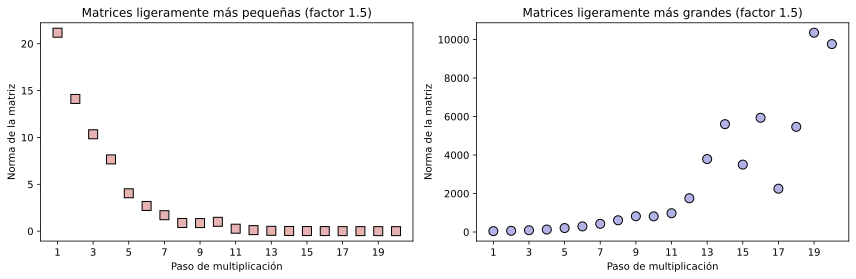

In [4]:
# Factor de escala
scalefact = 1.5

# Número de multiplicaciones (iteraciones)
nummults = 20

# Inicializar matrices aleatorias
Asmol = torch.randn(30, 30)
Abig = torch.randn(30, 30)

# Inicializar resultados
norms = torch.zeros(nummults, 2)

# Bucle sobre N multiplicaciones
for i in range(nummults):
  Asmol *= torch.randn(30, 30) * (1 / scalefact)
  norms[i, 0] = torch.norm(Asmol)

  Abig *= torch.randn(30, 30) * scalefact
  norms[i, 1] = torch.norm(Abig)


# Dibujar los gráficos
_, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(
    range(1, nummults + 1),
    norms[:, 0],
    'ks',
    markersize=9,
    markerfacecolor=[0.9, 0.7, 0.7],
)
axs[1].plot(
    range(1, nummults + 1),
    norms[:, 1],
    'ko',
    markersize=9,
    markerfacecolor=[0.7, 0.7, 0.9],
)

for a, t in zip(axs, ['más pequeñas', 'más grandes']):
  a.set(
      xticks=range(1, nummults + 1, 2),
      xlabel='Paso de multiplicación',
      ylabel='Norma de la matriz',
      title=f'Matrices ligeramente {t} (factor {scalefact})',
  )

plt.tight_layout()
plt.show()

## Creando una matriz (Matriz de Activación)

In [5]:

n_in  =  3
n_out = 10

A = torch.randn(n_in,n_out)*2 + 3
torch.round(A)

tensor([[ 0.,  4.,  1., -1.,  2., -1.,  5.,  5.,  6.,  3.],
        [ 4.,  3.,  4.,  1.,  5.,  5.,  2.,  5.,  3.,  1.],
        [ 6.,  3.,  2.,  5.,  3.,  4.,  8.,  1.,  5., -2.]])

## Creando una instancia del objeto Layernorm

In [6]:
layernorm = nn.LayerNorm(n_out)  # Repetir con (n_in, n_out)
layernorm

LayerNorm((10,), eps=1e-05, elementwise_affine=True)

## Aplicando Layernorm a los pesos de la Matriz

In [7]:
normA = layernorm(A)

print('Matriz original:\n', torch.round(A))
print('\nMatriz normalizada (LayerNorm):\n', torch.round(normA))

Matriz original:
 tensor([[ 0.,  4.,  1., -1.,  2., -1.,  5.,  5.,  6.,  3.],
        [ 4.,  3.,  4.,  1.,  5.,  5.,  2.,  5.,  3.,  1.],
        [ 6.,  3.,  2.,  5.,  3.,  4.,  8.,  1.,  5., -2.]])

Matriz normalizada (LayerNorm):
 tensor([[-1.,  1., -0., -1., -0., -1.,  1.,  1.,  1.,  0.],
        [ 1., -0.,  0., -2.,  1.,  1., -1.,  1., -0., -1.],
        [ 1., -0., -1.,  1., -0.,  0.,  2., -1.,  0., -2.]],
       grad_fn=<RoundBackward0>)


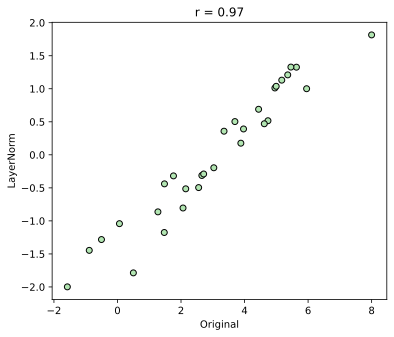

In [8]:
# ¿Cómo cambia la matriz LayerNorm?

# Variables de conveniencia
a1 = A.detach().flatten()
a2 = normA.detach().flatten()

# Correlación entre ellas
r = torch.sum((a1 - a1.mean()) * (a2 - a2.mean()))
r /= torch.sqrt(torch.sum((a1 - a1.mean()) ** 2) * torch.sum((a2 - a2.mean()) ** 2))

# ¡Gráfico de dispersión!
plt.figure(figsize=(6, 5))
plt.plot(a1, a2, 'ko', markerfacecolor=[0.7, 0.9, 0.7])

# Etiquetas, etc.
plt.gca().set(xlabel='Original', ylabel='LayerNorm', title=f'r = {r:.2f}')
plt.show()

In [9]:
print('ORIGINAL: media a través de las columnas para cada fila:')
print(f'  {torch.mean(A, axis=1)}\n')
print('LAYERNORM: media a través de las columnas para cada fila:')
print(f'  {torch.mean(normA, axis=1).detach()}\n')


print('ORIGINAL: desv. estándar a través de las columnas para cada fila:')
print(f'  {torch.std(A, axis=1)}\n')
print('LAYERNORM: desv. estándar a través de las columnas para cada fila:')
print(f'  {torch.std(normA, axis=1).detach()}\n')


print('\n\nLAYERNORM: media a través de las filas para cada columna:')
print(f'  {torch.mean(normA, axis=0).detach()}\n')
print('LAYERNORM: desv. estándar a través de las filas para cada columna:')
print(f'  {torch.std(normA, axis=0).detach()}\n')

ORIGINAL: media a través de las columnas para cada fila:
  tensor([2.5125, 3.3444, 3.4408])

LAYERNORM: media a través de las columnas para cada fila:
  tensor([4.7684e-08, 3.5763e-08, 4.1723e-08])

ORIGINAL: desv. estándar a través de las columnas para cada fila:
  tensor([2.4792, 1.6780, 2.6470])

LAYERNORM: desv. estándar a través de las columnas para cada fila:
  tensor([1.0541, 1.0541, 1.0541])



LAYERNORM: media a través de las filas para cada columna:
  tensor([ 0.2162, -0.1016, -0.1874, -0.8510,  0.1344,  0.0196,  0.7136,  0.4614,
         0.5337, -0.9388])

LAYERNORM: desv. estándar a través de las filas para cada columna:
  tensor([1.1005, 0.5319, 0.5029, 1.2106, 0.7602, 1.3938, 1.3588, 1.1504, 0.7633,
        1.1958])



## Inspeccionar los parametros de Layernorm

In [10]:
import torch.nn as nn

n_out = 10  # Agregando la definición de n_out
layernorm = nn.LayerNorm(n_out)
print(f"Valor de 'gamma' (parámetro de escala/estiramiento): {layernorm.weight}\n")
print(f"Valor de 'beta' (parámetro de desplazamiento): {layernorm.bias}\n")

Valor de 'gamma' (parámetro de escala/estiramiento): Parameter containing:
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], requires_grad=True)

Valor de 'beta' (parámetro de desplazamiento): Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], requires_grad=True)



In [11]:
normAnew = layernorm(A)

print('ORIGINAL: media a través de las columnas para cada fila:')
print(f'  {torch.mean(A, axis=1)}\n')
print('ORIGINAL: desv. estándar a través de las columnas para cada fila:')
print(f'  {torch.std(A, axis=1)}\n')

print('NUEVO LAYERNORM: media a través de las columnas para cada fila:')
print(f'  {torch.mean(normAnew, axis=1).detach()}\n')
print('NUEVO LAYERNORM: desv. estándar a través de las columnas para cada fila:')
print(f'  {torch.std(normAnew, axis=1).detach()}\n')

ORIGINAL: media a través de las columnas para cada fila:
  tensor([2.5125, 3.3444, 3.4408])

ORIGINAL: desv. estándar a través de las columnas para cada fila:
  tensor([2.4792, 1.6780, 2.6470])

NUEVO LAYERNORM: media a través de las columnas para cada fila:
  tensor([4.7684e-08, 3.5763e-08, 4.1723e-08])

NUEVO LAYERNORM: desv. estándar a través de las columnas para cada fila:
  tensor([1.0541, 1.0541, 1.0541])

